<a href="https://colab.research.google.com/github/aadithya-vimal/SamsungInnovationCampus/blob/main/Task1_TitanicDatasetAnalysis_29_4_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import seaborn as sns

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [42]:
#Find the number of missing values in each column
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [43]:
#Find which columns are numeric and which are non numeric
# Get numeric columns (int and float)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Get non-numeric columns (object, category, boolean)
non_numeric_cols = df.select_dtypes(exclude=['number']).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("Non-Numeric Columns:", non_numeric_cols)

Numeric Columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Non-Numeric Columns: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [44]:
#Find the outlier in the numeric columns
for col in numeric_cols:
  #Obtain the Q1 and Q3 values for the particular column
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  #Calculate IQR
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  #Obtain outliers
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f"Outliers in {col}: {len(outliers)} rows")


Outliers in survived: 0 rows
Outliers in pclass: 0 rows
Outliers in age: 11 rows
Outliers in sibsp: 46 rows
Outliers in parch: 213 rows
Outliers in fare: 116 rows


In [45]:
#Import the categorical values
# Select only categorical and object columns
categorical_df = df.select_dtypes(include=['object', 'category'])

# Display the categorical columns
print(categorical_df.columns.tolist())

# Preview the first few rows
categorical_df.head()

['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']


,sex,embarked,class,who,deck,embark_town,alive
0,male,S,Third,man,NaN,Southampton,no
1,female,C,First,woman,C,Cherbourg,yes
2,female,S,Third,woman,NaN,Southampton,yes
3,female,S,First,woman,C,Southampton,yes
4,male,S,Third,man,NaN,Southampton,no


In [46]:
#Normalize the numeric columns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_fix = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
df[cols_to_fix] = scaler.fit_transform(df[cols_to_fix])

print(df[cols_to_fix].head())

   survived  pclass       age  sibsp  parch      fare
0       0.0     1.0  0.271174  0.125    0.0  0.014151
1       1.0     0.0  0.472229  0.125    0.0  0.139136
2       1.0     1.0  0.321438  0.000    0.0  0.015469
3       1.0     0.0  0.434531  0.125    0.0  0.103644
4       0.0     1.0  0.434531  0.000    0.0  0.015713


In [47]:
#Find the distribution of each numeric column

numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
print(df[numeric_cols].describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    0.654321    0.367921    0.065376    0.063599    0.062858
std      0.486592    0.418036    0.182540    0.137843    0.134343    0.096995
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000
25%      0.000000    0.500000    0.247612    0.000000    0.000000    0.015440
50%      0.000000    1.000000    0.346569    0.000000    0.000000    0.028213
75%      1.000000    1.000000    0.472229    0.125000    0.000000    0.060508
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000


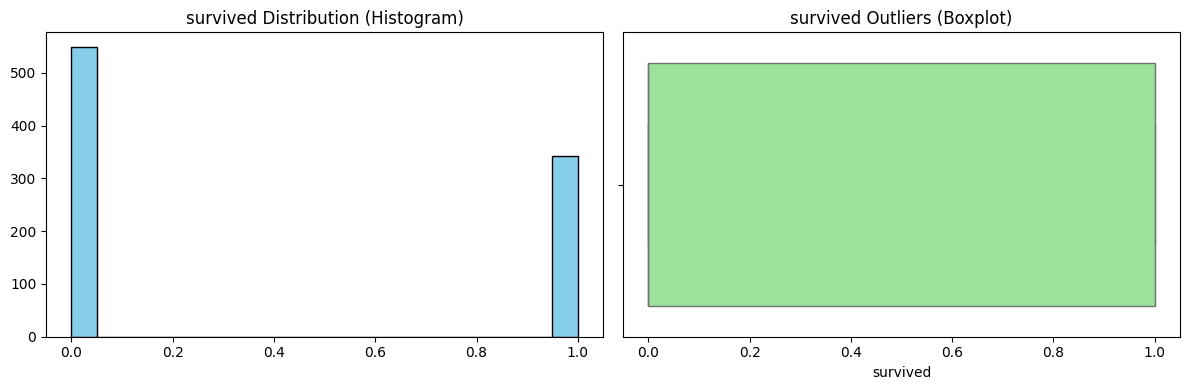

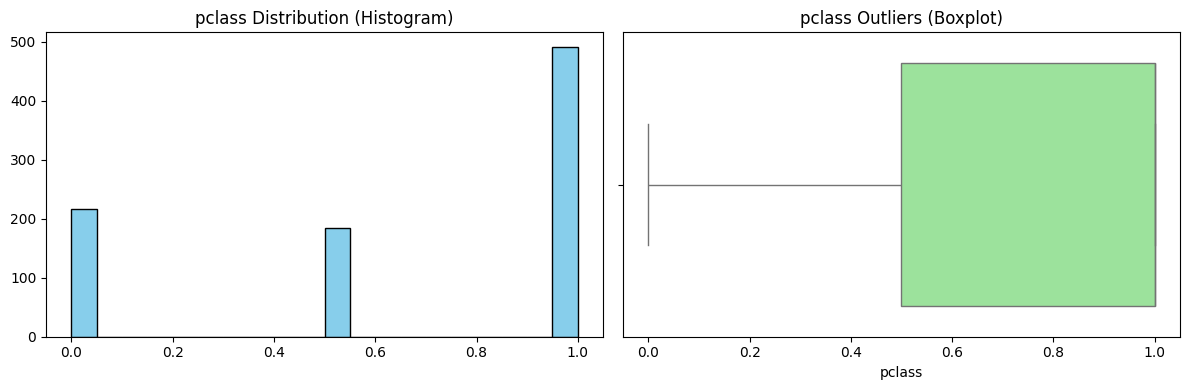

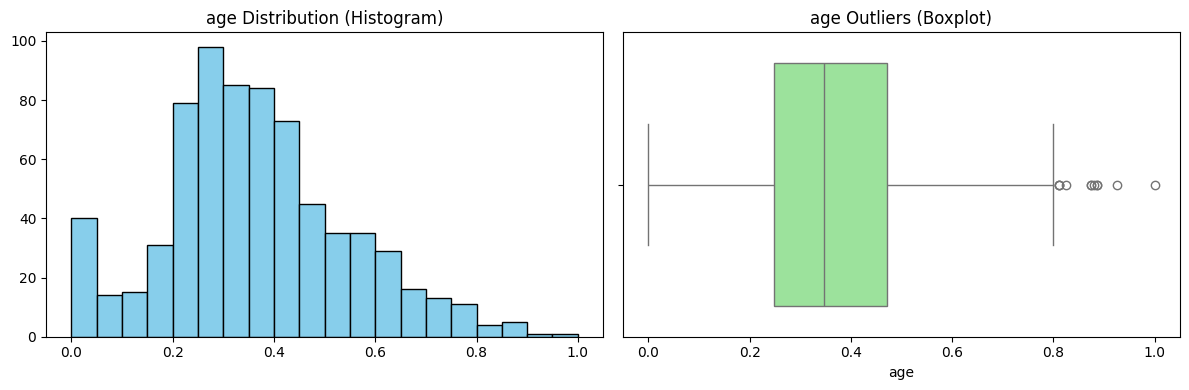

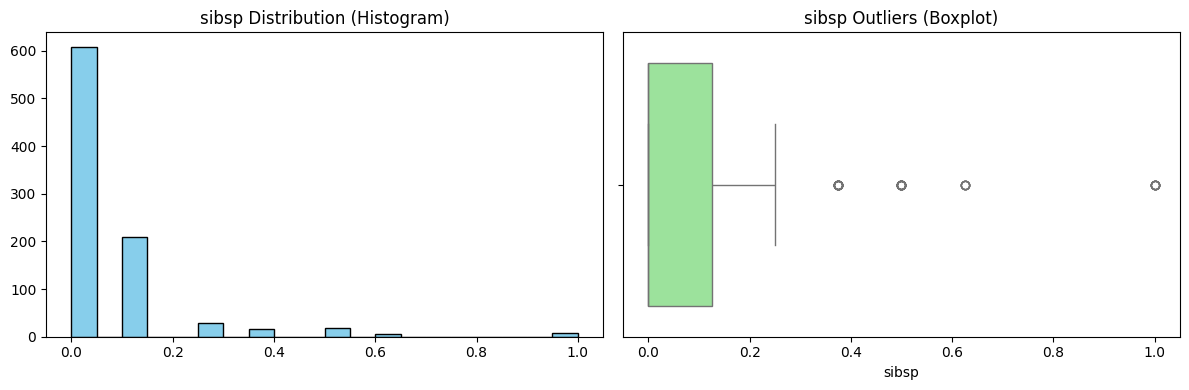

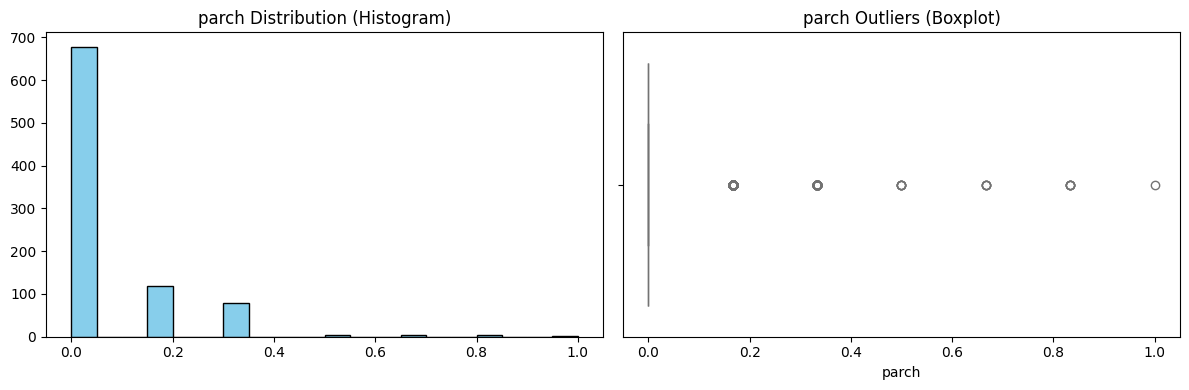

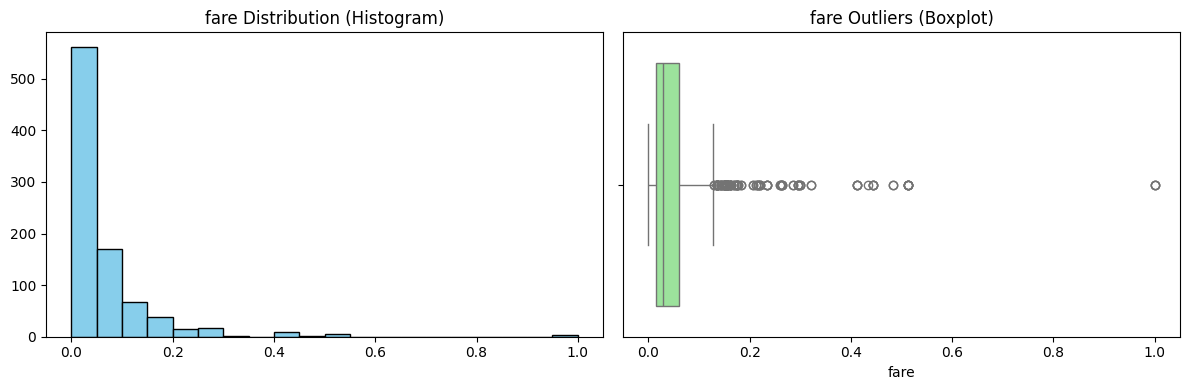

In [59]:
#Histogram and boxplot for each column

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

for col in numeric_cols:
    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # 1. Histogram
    ax1.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    ax1.set_title(f'{col} Distribution (Histogram)')

    # 2. Boxplot
    sns.boxplot(x=df[col], ax=ax2, color='lightgreen')
    ax2.set_title(f'{col} Outliers (Boxplot)')

    plt.tight_layout()
    plt.show()

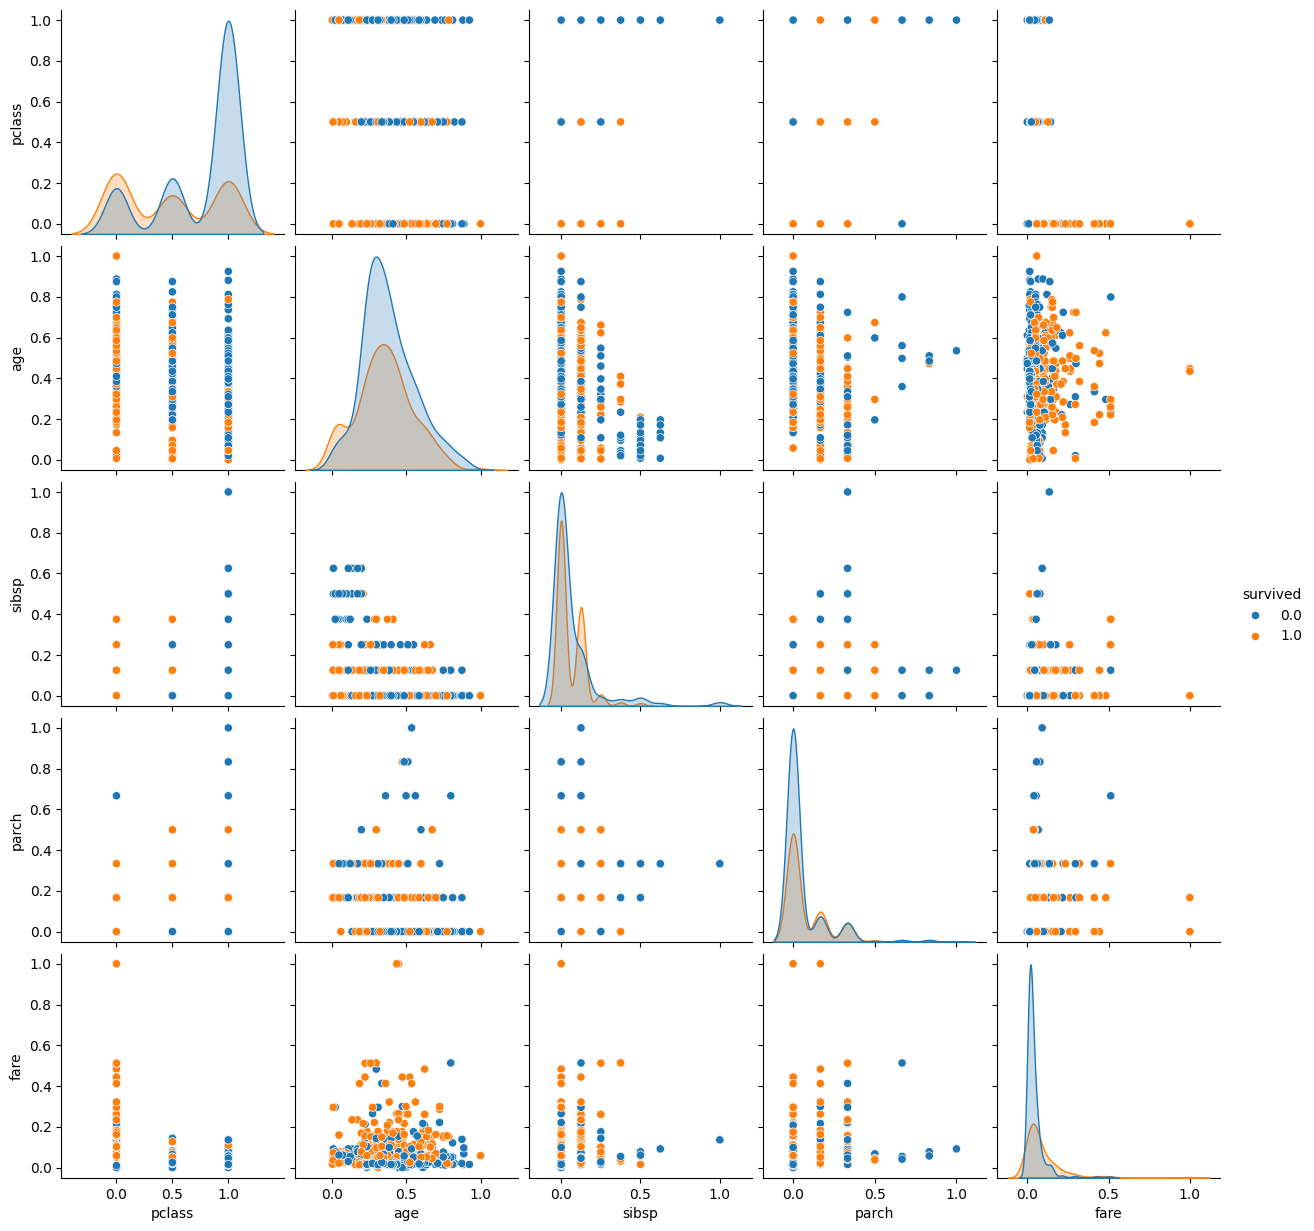

In [57]:
#Create a scatter plot for the numeric columns
# Select the columns you want to compare
cols_to_plot = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

# Create a grid of scatter plots
sns.pairplot(df[cols_to_plot], hue='survived', diag_kind='kde')
plt.show()

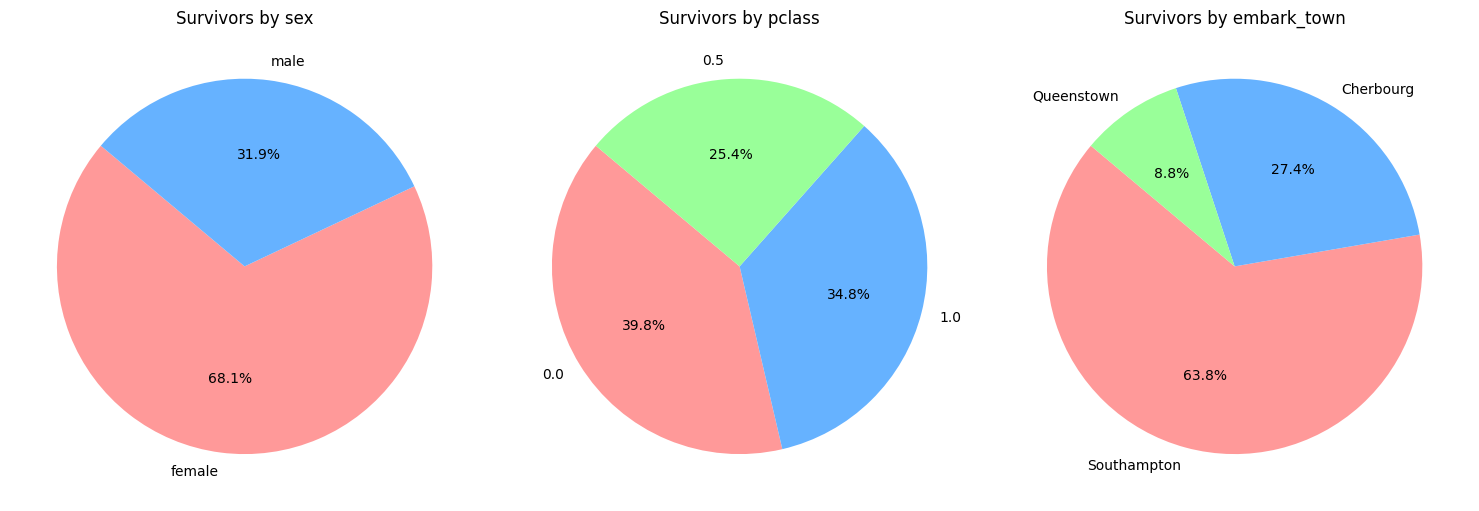

In [60]:
#Pie chart to show the percentage of survivors of each category
import matplotlib.pyplot as plt

# Filter the dataframe for survivors only
survivors_df = df[df['survived'] == 1]

# List of categories to visualize
categories = ['sex', 'pclass', 'embark_town']

plt.figure(figsize=(15, 5))

for i, col in enumerate(categories, 1):
    plt.subplot(1, 3, i)

    # Count survivors in each category
    counts = survivors_df[col].value_counts()

    # Create the pie chart
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
            startangle=140, colors=['#ff9999','#66b2ff','#99ff99'])

    plt.title(f'Survivors by {col}')

plt.tight_layout()
plt.show()

/tmp/ipykernel_19870/3646872654.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survival_pct.index, y=survival_pct.values, palette='magma')


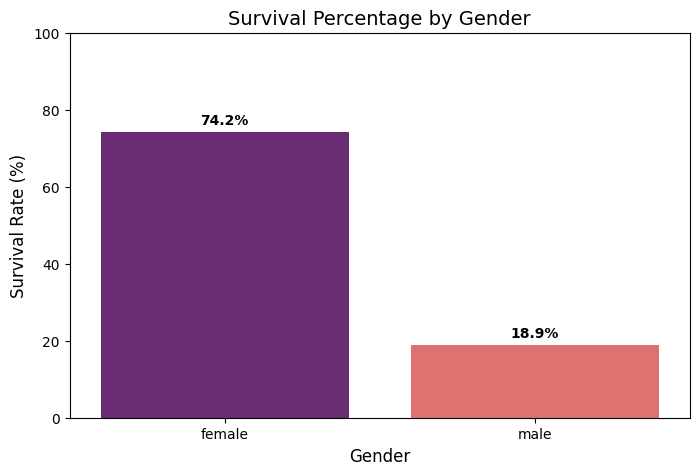

In [61]:
#Bar plot of gender wise survival percentage
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the survival percentage
# This groups by sex and finds the average of the 'survived' column
survival_pct = df.groupby('sex')['survived'].mean() * 100

# 2. Create the bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=survival_pct.index, y=survival_pct.values, palette='magma')

# Add labels and title
plt.title('Survival Percentage by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)
plt.ylim(0, 100) # Keep scale consistent 0-100%

# Add the percentage values on top of the bars
for i, val in enumerate(survival_pct.values):
    plt.text(i, val + 2, f'{val:.1f}%', ha='center', fontweight='bold')

plt.show()